# EDA — Reasoning types

Distribution of the eight reasoning types in the training set.

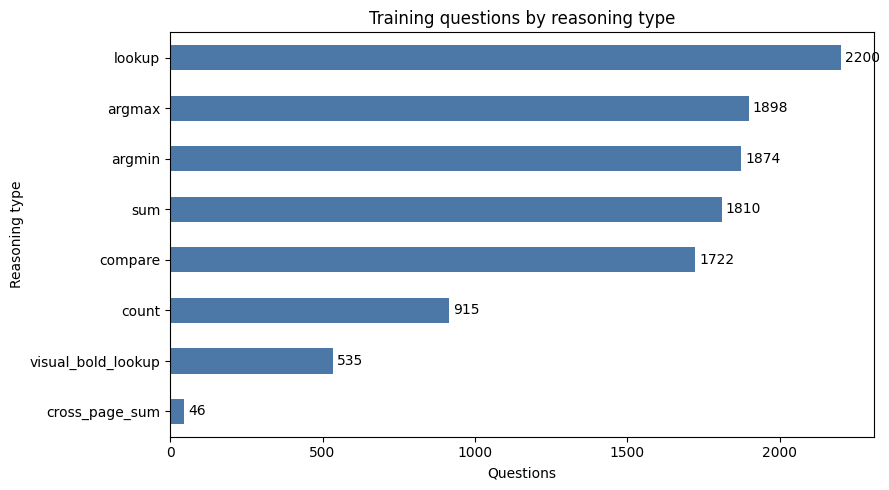

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path.cwd().resolve().parent / "data" / "training_set"
REASONING_TYPES = [
    "lookup", "argmax", "argmin", "sum", "compare", "count",
    "visual_bold_lookup", "cross_page_sum",
]

labels = pd.read_json(DATA_DIR / "labels.jsonl", lines=True)
counts = labels["reasoning_type"].value_counts().reindex(REASONING_TYPES, fill_value=0)

ax = counts.sort_values().plot.barh(figsize=(9, 5), color="#4C78A8")
ax.set(title="Training questions by reasoning type", xlabel="Questions", ylabel="Reasoning type")
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()


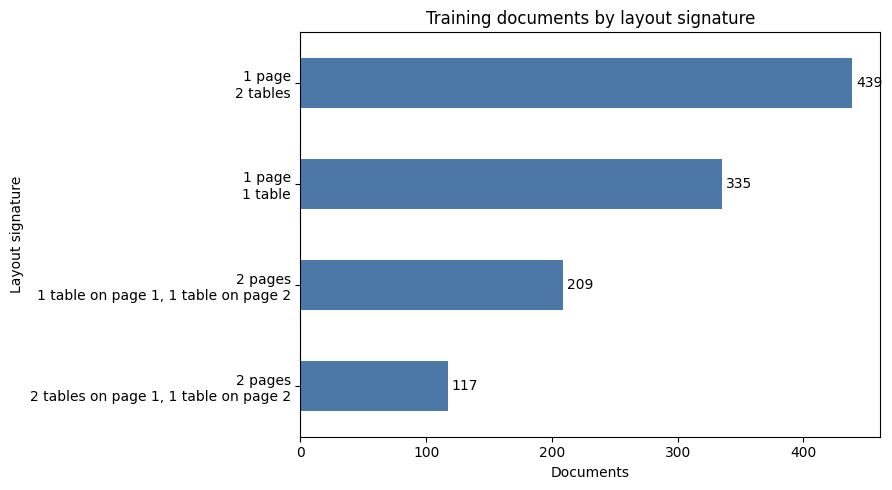

In [2]:
# Structural regularities: document layout signatures
manifest = pd.read_json(DATA_DIR / "manifest.jsonl", lines=True)
annotations = pd.read_json(DATA_DIR / "cell_annotations.jsonl", lines=True)
tables_by_page = annotations.groupby(["document_id", "page"])["table"].nunique()

def layout_signature(document):
    table_counts = [tables_by_page.get((document.id, page), 0) for page in range(1, len(document.image_paths) + 1)]
    pages = len(table_counts)
    page_label = f"{pages} page" if pages == 1 else f"{pages} pages"
    table_labels = [f"{count} table" if count == 1 else f"{count} tables" for count in table_counts]
    table_layout = table_labels[0] if pages == 1 else ", ".join(f"{label} on page {page}" for page, label in enumerate(table_labels, 1))
    return f"{page_label}\n{table_layout}"

layout_counts = manifest.apply(layout_signature, axis=1).value_counts().sort_values()
ax = layout_counts.plot.barh(figsize=(9, 5), color="#4C78A8")
ax.set(title="Training documents by layout signature", xlabel="Documents", ylabel="Layout signature")
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()


In [3]:
# Linguistic EDA setup: normalize only objectively variable surface forms
import re

questions = pd.read_json(DATA_DIR / "questions.jsonl", lines=True)
labels = pd.read_json(DATA_DIR / "labels.jsonl", lines=True)
question_types = questions.merge(labels[["question_id", "reasoning_type"]], on="question_id")

def normalize_question(question):
    question = question.lower().strip()
    question = re.sub(r'[\"“][^\"”]+[\"”]', '<QUOTE>', question)
    question = re.sub(r'\d+', '<NUM>', question)
    return re.sub(r'\s+', ' ', question)

question_types["normalized_question"] = question_types["question"].map(normalize_question)
question_types[["reasoning_type", "question", "normalized_question"]].head()


,reasoning_type,question,normalized_question
0,sum,"Trong bảng 1 ở trang 1, tổng Tuyển mới của hai...","trong bảng <NUM> ở trang <NUM>, tổng tuyển mới..."
1,lookup,"Trong bảng 1 ở trang 1, Tuyển mới của dòng có ...","trong bảng <NUM> ở trang <NUM>, tuyển mới của ..."
2,lookup,Hãy cho biết Hiện có tại bảng 1 ở trang 1 đối ...,hãy cho biết hiện có tại bảng <NUM> ở trang <N...
3,argmax,"Trong bảng 1 ở trang 1, Phòng ban nào có Tuyển...","trong bảng <NUM> ở trang <NUM>, phòng ban nào ..."
4,sum,"Trong bảng 1 ở trang 1, tổng Hiện có của hai d...","trong bảng <NUM> ở trang <NUM>, tổng hiện có c..."


In [4]:
# Discover frequent prefixes, suffixes, and n-grams without predefined cues
from collections import Counter

TOKEN_PATTERN = re.compile(r'<(?:NUM|QUOTE)>|\w+', re.UNICODE)

def tokens(text):
    return TOKEN_PATTERN.findall(text)

def top_phrases(texts, kind, width=4, limit=3):
    phrases = Counter()
    for text in texts:
        words = tokens(text)
        if len(words) < width:
            continue
        if kind == 'prefix':
            phrases[' '.join(words[:width])] += 1
        elif kind == 'suffix':
            phrases[' '.join(words[-width:])] += 1
        else:
            phrases.update(' '.join(words[index:index + width]) for index in range(len(words) - width + 1))
    return '; '.join(f'{phrase} ({count})' for phrase, count in phrases.most_common(limit))

rows = []
for reasoning_type, group in question_types.groupby('reasoning_type'):
    texts = group['normalized_question']
    rows.append({
        'reasoning_type': reasoning_type,
        'questions': len(group),
        'top prefixes': top_phrases(texts, 'prefix'),
        'top suffixes': top_phrases(texts, 'suffix'),
        'top 3-grams': top_phrases(texts, 'ngram', width=3),
        'top 5-grams': top_phrases(texts, 'ngram', width=5),
    })

wording_eda = pd.DataFrame(rows).sort_values('reasoning_type').reset_index(drop=True)
wording_eda


,reasoning_type,questions,top prefixes,top suffixes,top 3-grams,top 5-grams
0,argmax,1898,trong bảng <NUM> ở (1898),tỷ trọng lớn nhất (151); lũy kế lớn nhất (149)...,trong bảng <NUM> (1898); bảng <NUM> ở (1898); ...,trong bảng <NUM> ở trang (1898); bảng <NUM> ở ...
1,argmin,1874,trong bảng <NUM> ở (1874),kỳ trước nhỏ nhất (149); lũy kế nhỏ nhất (149)...,trong bảng <NUM> (1874); bảng <NUM> ở (1874); ...,trong bảng <NUM> ở trang (1874); bảng <NUM> ở ...
2,compare,1722,so sánh tại bảng (1722),lũy kế cao hơn (152); kỳ trước cao hơn (151); ...,so sánh tại (1722); sánh tại bảng (1722); tại ...,so sánh tại bảng <NUM> (1722); sánh tại bảng <...
3,count,915,có bao nhiêu dòng (915),vị tính là <QUOTE> (198); bổ sung là <QUOTE> (...,có bao nhiêu (915); bao nhiêu dòng (915); nhiê...,có bao nhiêu dòng trong (915); bao nhiêu dòng ...
4,cross_page_sum,46,lấy lũy kế của (6); lấy kế hoạch năm (4); lấy ...,quả là bao nhiêu (46),của dòng có (92); <QUOTE> ở trang (92); ở tran...,<QUOTE> ở trang <NUM> cộng (46); ở trang <NUM>...
5,lookup,2200,trong bảng <NUM> ở (841); tại bảng <NUM> ở (50...,thầu <QUOTE> là gì (61); đồng <QUOTE> là gì (5...,bảng <NUM> ở (2200); <NUM> ở trang (2200); ở t...,bảng <NUM> ở trang <NUM> (2200); tại bảng <NUM...
6,sum,1810,trong bảng <NUM> ở (1810),<QUOTE> là bao nhiêu (1810),trong bảng <NUM> (1810); bảng <NUM> ở (1810); ...,trong bảng <NUM> ở trang (1810); bảng <NUM> ở ...
7,visual_bold_lookup,535,tại bảng <NUM> ở (140); chỉ dựa vào hình (139)...,dòng đó là gì (139); cột đơn vị tính (24); cột...,bảng <NUM> ở (535); <NUM> ở trang (535); ở tra...,bảng <NUM> ở trang <NUM> (535); tại bảng <NUM>...


In [5]:
# Quote EDA: inspect whether quoted values recur as document-cell values
QUOTE_PATTERN = re.compile(r'[“\"]([^”\"]+)[”\"]')
question_types['quoted_spans'] = question_types['question'].map(lambda question: QUOTE_PATTERN.findall(question))

if 'annotations' not in globals():
    annotations = pd.read_json(DATA_DIR / 'cell_annotations.jsonl', lines=True)
cell_values_by_document = annotations.groupby('document_id')['clean_text'].agg(set)
quote_records = (
    question_types[['document_id', 'question_id', 'reasoning_type', 'question', 'quoted_spans']]
    .explode('quoted_spans')
    .dropna(subset=['quoted_spans'])
    .rename(columns={'quoted_spans': 'quoted_value'})
)
quote_records['matches_cell_annotation'] = quote_records.apply(
    lambda row: row.quoted_value in cell_values_by_document.get(row.document_id, set()), axis=1
)

quote_eda = (
    question_types.assign(quote_count=question_types['quoted_spans'].map(len))
    .groupby('reasoning_type')
    .agg(questions=('question_id', 'size'), questions_with_quotes=('quote_count', lambda counts: (counts > 0).sum()), total_quotes=('quote_count', 'sum'))
    .assign(quote_question_rate=lambda frame: frame.questions_with_quotes / frame.questions)
)
quote_eda['quote_cell_match_rate'] = quote_records.groupby('reasoning_type')['matches_cell_annotation'].mean()
quote_eda = quote_eda.fillna({'quote_cell_match_rate': 0}).sort_index()
display(quote_eda)

quote_records.groupby('reasoning_type', group_keys=False).head(3)[['reasoning_type', 'quoted_value', 'question']].sort_values('reasoning_type')


,questions,questions_with_quotes,total_quotes,quote_question_rate,quote_cell_match_rate
reasoning_type,,,,,
argmax,1898,0,0,0.0,0.0
argmin,1874,0,0,0.0,0.0
compare,1722,1722,5550,1.0,1.0
count,915,915,915,1.0,1.0
cross_page_sum,46,46,180,1.0,1.0
lookup,2200,2200,3690,1.0,1.0
sum,1810,1810,5834,1.0,1.0
visual_bold_lookup,535,535,1828,1.0,1.0


,reasoning_type,quoted_value,question
7,compare,Kinh doanh,So sánh tại bảng 1 ở trang 1: giữa dòng có Phò...
7,compare,23,So sánh tại bảng 1 ở trang 1: giữa dòng có Phò...
7,compare,Kế toán,So sánh tại bảng 1 ở trang 1: giữa dòng có Phò...
96,count,Thủ tục,Có bao nhiêu dòng trong bảng 1 ở trang 1 có Vư...
17,count,Đạt kế hoạch,Có bao nhiêu dòng trong bảng 1 ở trang 1 có Gh...
12,count,Lúa,Có bao nhiêu dòng trong bảng 1 ở trang 1 có Câ...
1035,cross_page_sum,Cần Thơ,Lấy Diện tích (ha) của dòng có Địa bàn “Hải Ph...
1035,cross_page_sum,Hải Phòng,Lấy Diện tích (ha) của dòng có Địa bàn “Hải Ph...
1035,cross_page_sum,Thanh long,Lấy Diện tích (ha) của dòng có Địa bàn “Hải Ph...
1,lookup,Kinh doanh,"Trong bảng 1 ở trang 1, Tuyển mới của dòng có ..."


In [6]:
# Discover n-grams that are distinctive for each reasoning type
from math import ceil

def question_ngrams(text, max_width=5):
    words = tokens(text)
    return {
        ' '.join(words[start:start + width])
        for width in range(1, max_width + 1)
        for start in range(len(words) - width + 1)
    }

documents_by_type = {
    reasoning_type: [question_ngrams(text) for text in group['normalized_question']]
    for reasoning_type, group in question_types.groupby('reasoning_type')
}
document_frequency = Counter(ngram for documents in documents_by_type.values() for document in documents for ngram in document)
total_questions = len(question_types)

rows = []
for reasoning_type, documents in documents_by_type.items():
    within_frequency = Counter(ngram for document in documents for ngram in document)
    within_total = len(documents)
    minimum_count = max(2, ceil(within_total * 0.02))
    candidates = []
    for ngram, within_count in within_frequency.items():
        if within_count < minimum_count:
            continue
        within_rate = within_count / within_total
        outside_rate = (document_frequency[ngram] - within_count) / (total_questions - within_total)
        candidates.append((within_rate - outside_rate, within_rate, outside_rate, ngram))
    top = sorted(candidates, reverse=True)[:5]
    rows.append({
        'reasoning_type': reasoning_type,
        'distinctive n-grams (within type; outside type)': '; '.join(
            f'{ngram} ({within_rate:.0%}; {outside_rate:.0%})'
            for _, within_rate, outside_rate, ngram in top
        ),
    })

discriminative_eda = pd.DataFrame(rows).sort_values('reasoning_type').reset_index(drop=True)
discriminative_eda


,reasoning_type,distinctive n-grams (within type; outside type)
0,argmax,lớn nhất (100%; 0%); lớn (100%; 0%); nhất (100...
1,argmin,nhỏ nhất (100%; 0%); nhỏ (100%; 0%); nhất (100...
2,compare,với dòng có (100%; 0%); với dòng (100%; 0%); t...
3,count,ở trang <NUM> có (100%; 0%); trang <NUM> có (1...
4,cross_page_sum,ở trang <NUM> kết quả (100%; 0%); ở trang <NUM...
5,lookup,<QUOTE> (100%; 57%); tại bảng <NUM> ở trang (6...
6,sum,ở trang <NUM> tổng (100%; 0%); tổng (100%; 0%)...
7,visual_bold_lookup,ảnh (100%; 0%); đậm (100%; 0%); in đậm (100%; ...


In [7]:
# Inspect representative raw questions for the most common prefix variants
TOP_PREFIXES_PER_TYPE = 4
EXAMPLES_PER_PREFIX = 3

def prefix_variant(text, width=4):
    return ' '.join(tokens(text)[:width])

raw_examples = question_types.copy()
raw_examples['prefix_variant'] = raw_examples['normalized_question'].map(prefix_variant)
prefix_counts = (
    raw_examples.groupby(['reasoning_type', 'prefix_variant'])
    .size()
    .rename('prefix_questions')
    .reset_index()
    .sort_values(['reasoning_type', 'prefix_questions', 'prefix_variant'], ascending=[True, False, True])
)
top_prefixes = prefix_counts.groupby('reasoning_type', group_keys=False).head(TOP_PREFIXES_PER_TYPE)
representative_questions = (
    raw_examples.merge(top_prefixes, on=['reasoning_type', 'prefix_variant'])
    .sort_values(['reasoning_type', 'prefix_questions', 'prefix_variant', 'question_id'], ascending=[True, False, True, True])
    .groupby(['reasoning_type', 'prefix_variant'], group_keys=False)
    .head(EXAMPLES_PER_PREFIX)
    [['reasoning_type', 'prefix_variant', 'prefix_questions', 'question_id', 'question']]
    .reset_index(drop=True)
)
pd.set_option('display.max_colwidth', None)
representative_questions


,reasoning_type,prefix_variant,prefix_questions,question_id,question
0,argmax,trong bảng <NUM> ở,1898,B-train-00000-q04,"Trong bảng 1 ở trang 1, Phòng ban nào có Tuyển mới lớn nhất?"
1,argmax,trong bảng <NUM> ở,1898,B-train-00000-q10,"Trong bảng 1 ở trang 1, Phòng ban nào có Định biên lớn nhất?"
2,argmax,trong bảng <NUM> ở,1898,B-train-00001-q06,"Trong bảng 1 ở trang 1, Địa bàn nào có Diện tích (ha) lớn nhất?"
3,argmin,trong bảng <NUM> ở,1874,B-train-00000-q07,"Trong bảng 1 ở trang 1, Phòng ban nào có Hiện có nhỏ nhất?"
4,argmin,trong bảng <NUM> ở,1874,B-train-00000-q09,"Trong bảng 1 ở trang 1, Phòng ban nào có Định biên nhỏ nhất?"
5,argmin,trong bảng <NUM> ở,1874,B-train-00001-q02,"Trong bảng 1 ở trang 1, Địa bàn nào có Diện tích (ha) nhỏ nhất?"
6,compare,so sánh tại bảng,1722,B-train-00000-q08,"So sánh tại bảng 1 ở trang 1: giữa dòng có Phòng ban “Kinh doanh” và Định biên “23” với dòng có Phòng ban “Kế toán” và Định biên “34”, dòng nào có Thiếu/thừa cao hơn?"
7,compare,so sánh tại bảng,1722,B-train-00001-q10,"So sánh tại bảng 1 ở trang 1: giữa dòng có Địa bàn “Đà Nẵng” với dòng có Địa bàn “Đồng Nai”, dòng nào có Diện tích (ha) cao hơn?"
8,compare,so sánh tại bảng,1722,B-train-00002-q03,"So sánh tại bảng 1 ở trang 1: giữa dòng có Trạm “Trạm 110kV Bắc” và Sản lượng “15.838” với dòng có Trạm “Trạm Nam Sông”, dòng nào có Công suất đỉnh cao hơn?"
9,count,có bao nhiêu dòng,915,B-train-00001-q03,Có bao nhiêu dòng trong bảng 1 ở trang 1 có Cây trồng là “Lúa”?


Cross-page question: Lấy Diện tích (ha) của dòng có Địa bàn “Hải Phòng” và Cây trồng “Thanh long” ở trang 1 cộng với Diện tích (ha) của dòng có Địa bàn “Cần Thơ” và Cây trồng “Lúa” ở trang 2. Kết quả là bao nhiêu?
Visual-bold question: OCR không ghi nhận định dạng chữ. Trong ảnh của bảng 1 ở trang 1, hãy chọn dòng in đậm giữa Phòng ban “Vận hành” và Phòng ban “Kế toán” và Định biên “30”, rồi đọc ô thuộc cột Hiện có.


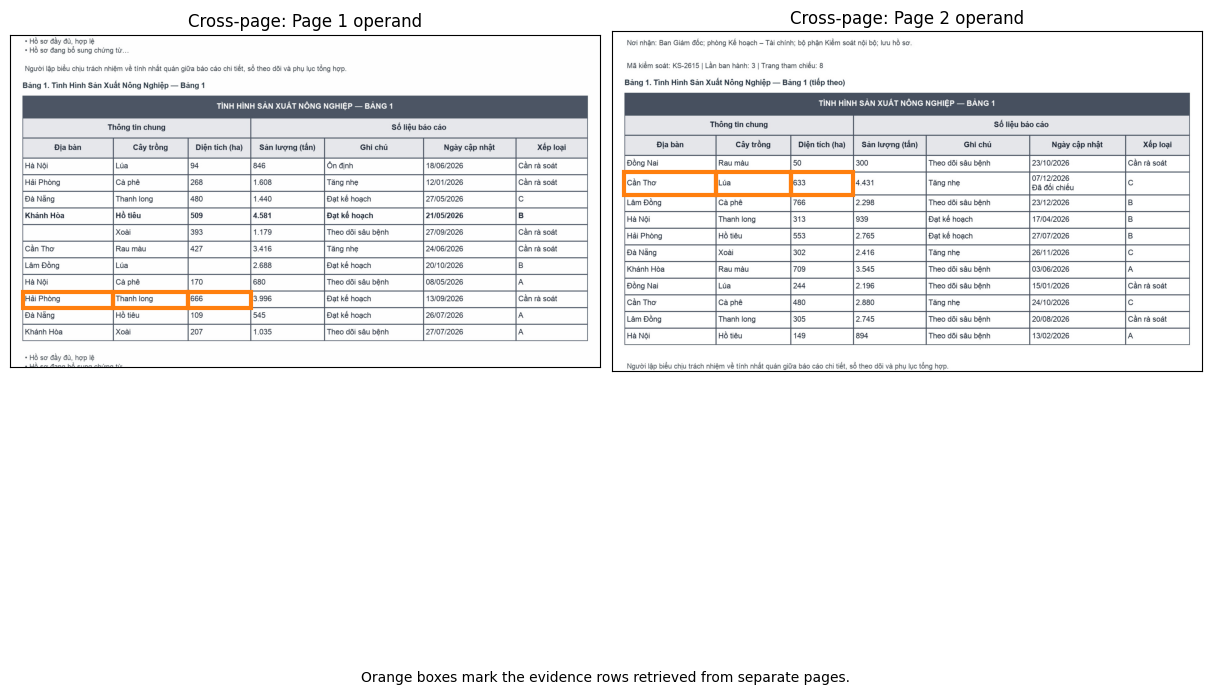

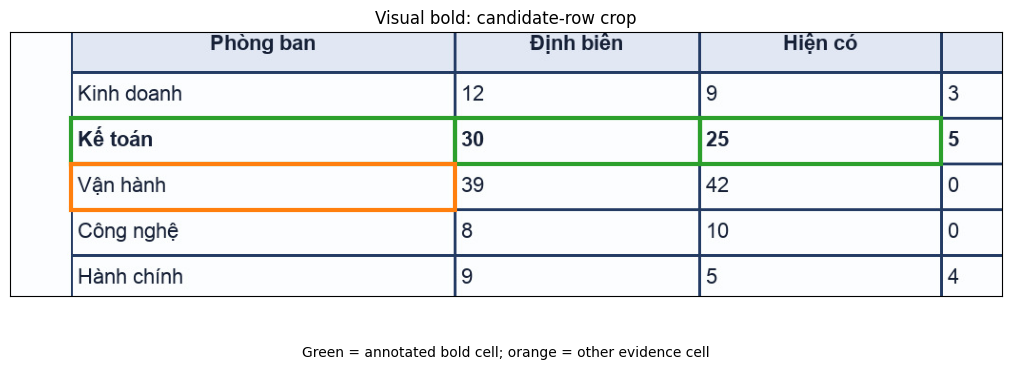

In [8]:
# Real document images for the cross-page and visual-bold pipeline exceptions
from PIL import Image
from matplotlib.patches import Rectangle

if 'annotations' not in globals():
    annotations = pd.read_json(DATA_DIR / 'cell_annotations.jsonl', lines=True)
manifests = pd.read_json(DATA_DIR / 'manifest.jsonl', lines=True).set_index('id')
labels_by_question = labels.set_index('question_id')
annotation_by_block = {(row.document_id, row.block_id): row for row in annotations.itertuples()}

cross_example = question_types.query("reasoning_type == 'cross_page_sum'").iloc[0]
visual_example = question_types.query("reasoning_type == 'visual_bold_lookup'").iloc[0]

def evidence_for(question_id):
    return labels_by_question.loc[question_id, 'evidence']

def page_image(document_id, page):
    return Image.open(DATA_DIR / manifests.loc[document_id, 'image_paths'][page - 1]).convert('RGB')

def draw_evidence(ax, document_id, page, evidence, title, crop_to_evidence=False, crop_to_table=False):
    image = page_image(document_id, page)
    source_width, source_height = image.size
    page_evidence = [item for item in evidence if item['page'] == page]
    left = top = 0
    if crop_to_evidence or crop_to_table:
        if crop_to_table:
            table = annotation_by_block[(document_id, page_evidence[0]['block_id'])].table
            cells = annotations[(annotations['document_id'] == document_id) & (annotations['page'] == page) & (annotations['table'] == table)]
            boxes = cells['bbox'].tolist()
            x1, y1 = min(box[0] for box in boxes), min(box[1] for box in boxes)
            x2, y2 = max(box[2] for box in boxes), max(box[3] for box in boxes)
            x1, y1, x2, y2 = max(0, x1 - 0.02), max(0, y1 - 0.07), min(1, x2 + 0.02), min(1, y2 + 0.03)
        else:
            x1 = max(0, min(item['bbox'][0] for item in page_evidence) - 0.04)
            y1 = max(0, min(item['bbox'][1] for item in page_evidence) - 0.04)
            x2 = min(1, max(item['bbox'][2] for item in page_evidence) + 0.04)
            y2 = min(1, max(item['bbox'][3] for item in page_evidence) + 0.04)
        left, top = x1, y1
        image = image.crop((x1 * source_width, y1 * source_height, x2 * source_width, y2 * source_height))
    ax.imshow(image)
    for item in page_evidence:
        x1, y1, x2, y2 = item['bbox']
        annotation = annotation_by_block.get((document_id, item['block_id']))
        is_bold = bool(annotation and annotation.is_bold)
        color = '#2CA02C' if is_bold else '#FF7F0E'
        ax.add_patch(Rectangle(((x1 - left) * source_width, (y1 - top) * source_height), (x2 - x1) * source_width, (y2 - y1) * source_height, fill=False, edgecolor=color, linewidth=3))
    ax.set(title=title, xticks=[], yticks=[])

cross_evidence = evidence_for(cross_example.question_id)
visual_evidence = evidence_for(visual_example.question_id)
print('Cross-page question:', cross_example.question)
print('Visual-bold question:', visual_example.question)

fig, axes = plt.subplots(1, 2, figsize=(12, 10), constrained_layout=True)
draw_evidence(axes[0], cross_example.document_id, 1, cross_evidence, 'Cross-page: Page 1 operand', crop_to_table=True)
draw_evidence(axes[1], cross_example.document_id, 2, cross_evidence, 'Cross-page: Page 2 operand', crop_to_table=True)
fig.text(0.5, 0.02, 'Orange boxes mark the evidence rows retrieved from separate pages.', ha='center')
plt.show()

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
draw_evidence(ax, visual_example.document_id, 1, visual_evidence, 'Visual bold: candidate-row crop', crop_to_evidence=True)
fig.text(0.5, 0.02, 'Green = annotated bold cell; orange = other evidence cell', ha='center')
plt.show()


In [16]:
# Aggregate validation: are annotated cells regular enough for geometric reconstruction?
# The two checks mirror the baseline rules: group cells into rows by y, then map cells to headers by x.
GEOMETRY_TOLERANCE = 0.005  # 0.5% of page height/width; bboxes are normalized to [0, 1]
TABLE_KEYS = ['document_id', 'page', 'table']

geometry = annotations.copy()
geometry[['x1', 'y1', 'x2', 'y2']] = pd.DataFrame(geometry['bbox'].tolist(), index=geometry.index)
data_cells = geometry[~geometry['is_header']].copy()

# A logical row is geometrically regular when all of its cells begin on the same horizontal line.
row_groups = (
    data_cells.groupby(TABLE_KEYS + ['row'])
    .agg(cells=('block_id', 'size'), y1_span=('y1', lambda values: values.max() - values.min()))
    .query('cells >= 2')
)
row_alignment_rate = (row_groups['y1_span'] <= GEOMETRY_TOLERANCE).mean()

# Use the lowest header in each column: this is the leaf header that names the data column.
headers = geometry[geometry['is_header']].copy()
headers['header_x'] = (headers['x1'] + headers['x2']) / 2
leaf_headers = (
    headers.sort_values(TABLE_KEYS + ['column', 'y1', 'y2'])
    .groupby(TABLE_KEYS + ['column'], as_index=False)
    .tail(1)
)
header_centers = leaf_headers[
    TABLE_KEYS + ['column', 'clean_text', 'header_x']
].rename(columns={'clean_text': 'header_text'})
header_mapped_cells = data_cells.merge(header_centers, on=TABLE_KEYS + ['column'], how='inner')
column_alignment_rate = (
    (header_mapped_cells['x1'] - GEOMETRY_TOLERANCE <= header_mapped_cells['header_x'])
    & (header_mapped_cells['header_x'] <= header_mapped_cells['x2'] + GEOMETRY_TOLERANCE)
).mean()

geometry_audit = pd.DataFrame([
    {'check': 'Rows with aligned top edges', 'rate': row_alignment_rate, 'units': len(row_groups)},
    {'check': 'Data cells covered by header center', 'rate': column_alignment_rate, 'units': len(header_mapped_cells)},
    {'check': 'Data cells with an annotated header column', 'rate': len(header_mapped_cells) / len(data_cells), 'units': len(data_cells)},
])
geometry_audit['rate'] = geometry_audit['rate'].map('{:.1%}'.format)
display(geometry_audit)

# Inspect a reproducible sample of cells where the simple header-center rule does not apply.
misaligned_cells = header_mapped_cells.loc[~(
    (header_mapped_cells['x1'] - GEOMETRY_TOLERANCE <= header_mapped_cells['header_x'])
    & (header_mapped_cells['header_x'] <= header_mapped_cells['x2'] + GEOMETRY_TOLERANCE)
)].copy()
misaligned_cells['cell_bbox'] = misaligned_cells[['x1', 'y1', 'x2', 'y2']].round(4).values.tolist()
sample_size = min(20, len(misaligned_cells))
display(misaligned_cells.sample(sample_size, random_state=42)[
    TABLE_KEYS + ['row', 'column', 'clean_text', 'cell_bbox', 'header_text', 'header_x']
].sort_values(TABLE_KEYS + ['row', 'column']).reset_index(drop=True))

print(
    'Interpretation: high rates support the baseline geometry rules; low rates identify where OCR/layout fallbacks are needed.'
)


,check,rate,units
0,Rows with aligned top edges,100.0%,24936
1,Data cells covered by header center,100.0%,231618
2,Data cells with an annotated header column,100.0%,231618


,document_id,page,table,row,column,clean_text,cell_bbox,header_text,header_x


Interpretation: high rates support the baseline geometry rules; low rates identify where OCR/layout fallbacks are needed.


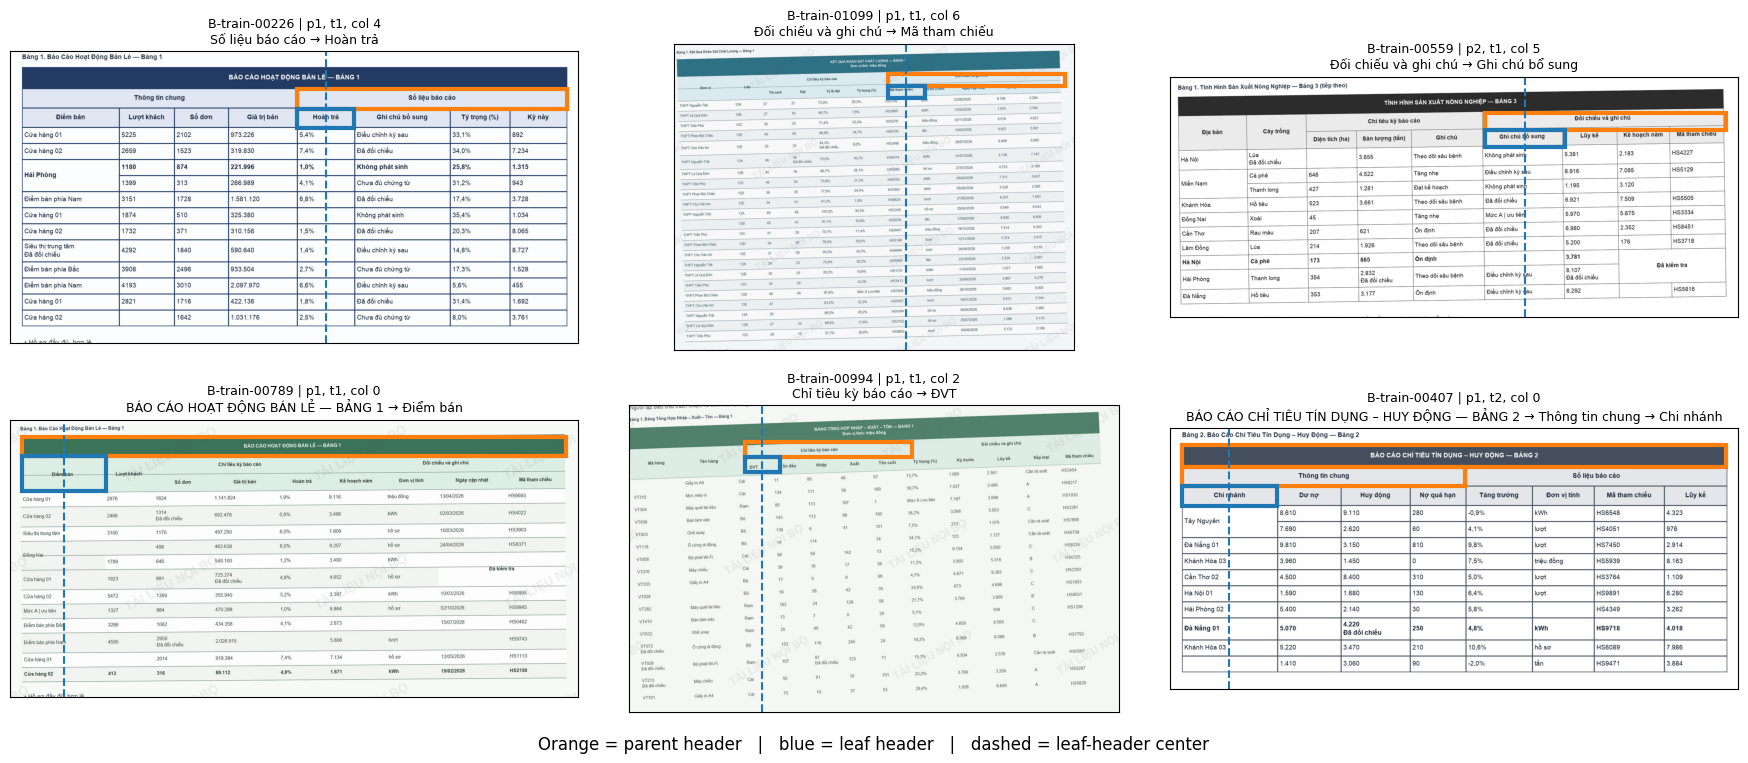

In [15]:
# Visual inspection: examples of hierarchical headers in the training set.
from matplotlib.patches import Rectangle
from PIL import Image

VISUAL_SAMPLES = 6
manifest_index = manifest.set_index('id')
hierarchical_columns = (
    headers.groupby(TABLE_KEYS + ['column'])
    .agg(header_levels=('y1', 'nunique'), header_labels=('clean_text', lambda values: ' → '.join(values)))
    .query('header_levels > 1')
    .reset_index()
)
visual_samples = hierarchical_columns.sample(min(VISUAL_SAMPLES, len(hierarchical_columns)), random_state=42)
fig, axes = plt.subplots(2, 3, figsize=(18, 7.5))
fig.subplots_adjust(left=0.02, right=0.98, top=0.96, bottom=0.07, wspace=0.02, hspace=0.18)

for ax, (_, sample) in zip(axes.flat, visual_samples.iterrows()):
    document_id, page, table, column = (sample[key] for key in TABLE_KEYS + ['column'])
    table_cells = geometry[(geometry['document_id'] == document_id) & (geometry['page'] == page) & (geometry['table'] == table)]
    x1, y1 = table_cells[['x1', 'y1']].min() - 0.02
    x2, y2 = table_cells[['x2', 'y2']].max() + 0.02
    x1, y1, x2, y2 = max(0, x1), max(0, y1), min(1, x2), min(1, y2)

    image = Image.open(DATA_DIR / manifest_index.loc[document_id, 'image_paths'][int(page) - 1]).convert('RGB')
    width, height = image.size
    ax.imshow(image.crop((x1 * width, y1 * height, x2 * width, y2 * height)))

    def draw_box(box, color, linewidth=2):
        bx1, by1, bx2, by2 = box
        ax.add_patch(Rectangle(((bx1 - x1) * width, (by1 - y1) * height), (bx2 - bx1) * width, (by2 - by1) * height, fill=False, edgecolor=color, linewidth=linewidth))

    column_headers = headers[(headers['document_id'] == document_id) & (headers['page'] == page) & (headers['table'] == table) & (headers['column'] == column)].sort_values('y1')
    for position, (_, header) in enumerate(column_headers.iterrows()):
        color = '#1f77b4' if position == len(column_headers) - 1 else '#ff7f0e'
        draw_box([header.x1, header.y1, header.x2, header.y2], color, linewidth=3)
    leaf_header = column_headers.iloc[-1]
    ax.axvline((leaf_header['header_x'] - x1) * width, color='#1f77b4', linestyle='--', linewidth=1.5)
    labels = ' → '.join(column_headers['clean_text'])
    ax.set_title(f"{document_id} | p{page}, t{table}, col {column}\n{labels}", fontsize=9)
    ax.set(xticks=[], yticks=[])

for ax in axes.flat[len(visual_samples):]:
    ax.axis('off')
fig.text(0.5, 0.02, 'Orange = parent header   |   blue = leaf header   |   dashed = leaf-header center', ha='center', fontsize=12)
plt.show()
